# Carga de datos — ISSSTE, IMSS e IMSS Bienestar

Este notebook carga los tres datasets de surtimiento de recetas y los prepara para el modelo Beta-Binomial jerárquico.

| Institución | Fuente | Granularidad | Estados | Años |
|---|---|---|---|---|
| ISSSTE | CSV (`agg_folio_2018_2024.csv`) | Anual (agregado desde mensual) | 32 | 2018–2024 |
| IMSS | Excel (hoja `Recetas`) | Anual | 32 | 2019–2024* |
| IMSS Bienestar | Excel (4 hojas wide) | Anual | 20 | 2017–2024* |

\* Datos de 2024 parciales (hasta abril).

In [5]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Añadir src/ al path para importar módulos locales
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))

from load_data_david import load_all, load_issste, load_imss, load_sedena, load_semar, load_imss_bienestar
from bayes_data import build_model_inputs

DATA_DIR = ROOT / 'data'
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## 1. Carga individual por institución

In [6]:
issste = load_issste(DATA_DIR / 'agg_folio_2018_2024.csv')
imss   = load_imss(DATA_DIR / 'IMSS_2019_ABRIL2024_ANUAL_SOLICITUD 330018024016694 ANEXO I.xlsx')
bw     = load_imss_bienestar(DATA_DIR / 'IMSS_BIENESTAR_2017_ABRIL2024_ANUAL_SOLICITUD 330018024016695 ANEXO I.xlsx')
sedena = load_sedena(DATA_DIR / 'SEDENA_2021_ABRIL2024_ANEXO FOLIO 330026424001543.xlsx')
semar  = load_semar(DATA_DIR / 'SEMAR_2017_ABRIL2024_ANEXO.xlsx')

for nombre, df in [('ISSSTE', issste), ('IMSS', imss), ('IMSS Bienestar', bw), ('SEDENA', sedena), ('SEMAR', semar)]:
    print(f"{'='*50}")
    print(f"  {nombre}  |  {df.shape[0]} filas  |  {df.estado.nunique()} estados  |  años: {sorted(df.anio.unique())}")
    print(df.to_string(index=False))

  ISSSTE  |  224 filas  |  32 estados  |  años: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
             estado  anio  surtidas   total institucion
     AGUASCALIENTES  2018    499160  503813      ISSSTE
     AGUASCALIENTES  2019    470536  477426      ISSSTE
     AGUASCALIENTES  2020    351012  372130      ISSSTE
     AGUASCALIENTES  2021    350040  359803      ISSSTE
     AGUASCALIENTES  2022    457139  466302      ISSSTE
     AGUASCALIENTES  2023    506976  515213      ISSSTE
     AGUASCALIENTES  2024    489385  504324      ISSSTE
    BAJA CALIFORNIA  2018    667804  681223      ISSSTE
    BAJA CALIFORNIA  2019    609113  629036      ISSSTE
    BAJA CALIFORNIA  2020    495058  537997      ISSSTE
    BAJA CALIFORNIA  2021    492065  522899      ISSSTE
    BAJA CALIFORNIA  2022    583478  613154      ISSSTE
    BAJA CALIFORNIA  2023    661711  688186      ISSSTE
    BAJA CALIFORNIA  2024    749718  772995      ISSSTE

## 2. Dataset unificado

In [7]:
df = load_all(DATA_DIR)
df['theta_obs'] = df['surtidas'] / df['total']

print(f"Total de observaciones: {len(df)}")
print()
display(
    df.groupby('institucion').agg(
        estados=('estado', 'nunique'),
        anios=('anio', 'nunique'),
        filas=('estado', 'count'),
        recetas_total=('total', 'sum'),
        recetas_surtidas=('surtidas', 'sum'),
    ).assign(
        theta_global=lambda x: x['recetas_surtidas'] / x['recetas_total']
    ).round({'theta_global': 4})
)

Total de observaciones: 738



,estados,anios,filas,recetas_total,recetas_surtidas,theta_global
institucion,,,,,,
IMSS,32,6,192,1212867806,1150318301,0.9484
IMSS Bienestar,20,8,160,20525728,19167060,0.9338
ISSSTE,32,7,224,238863549,233332377,0.9768
SEDENA,24,3,72,4632858,3515178,0.7587
SEMAR,18,5,90,3134197,2493917,0.7957


## 3. Cobertura temporal por institución

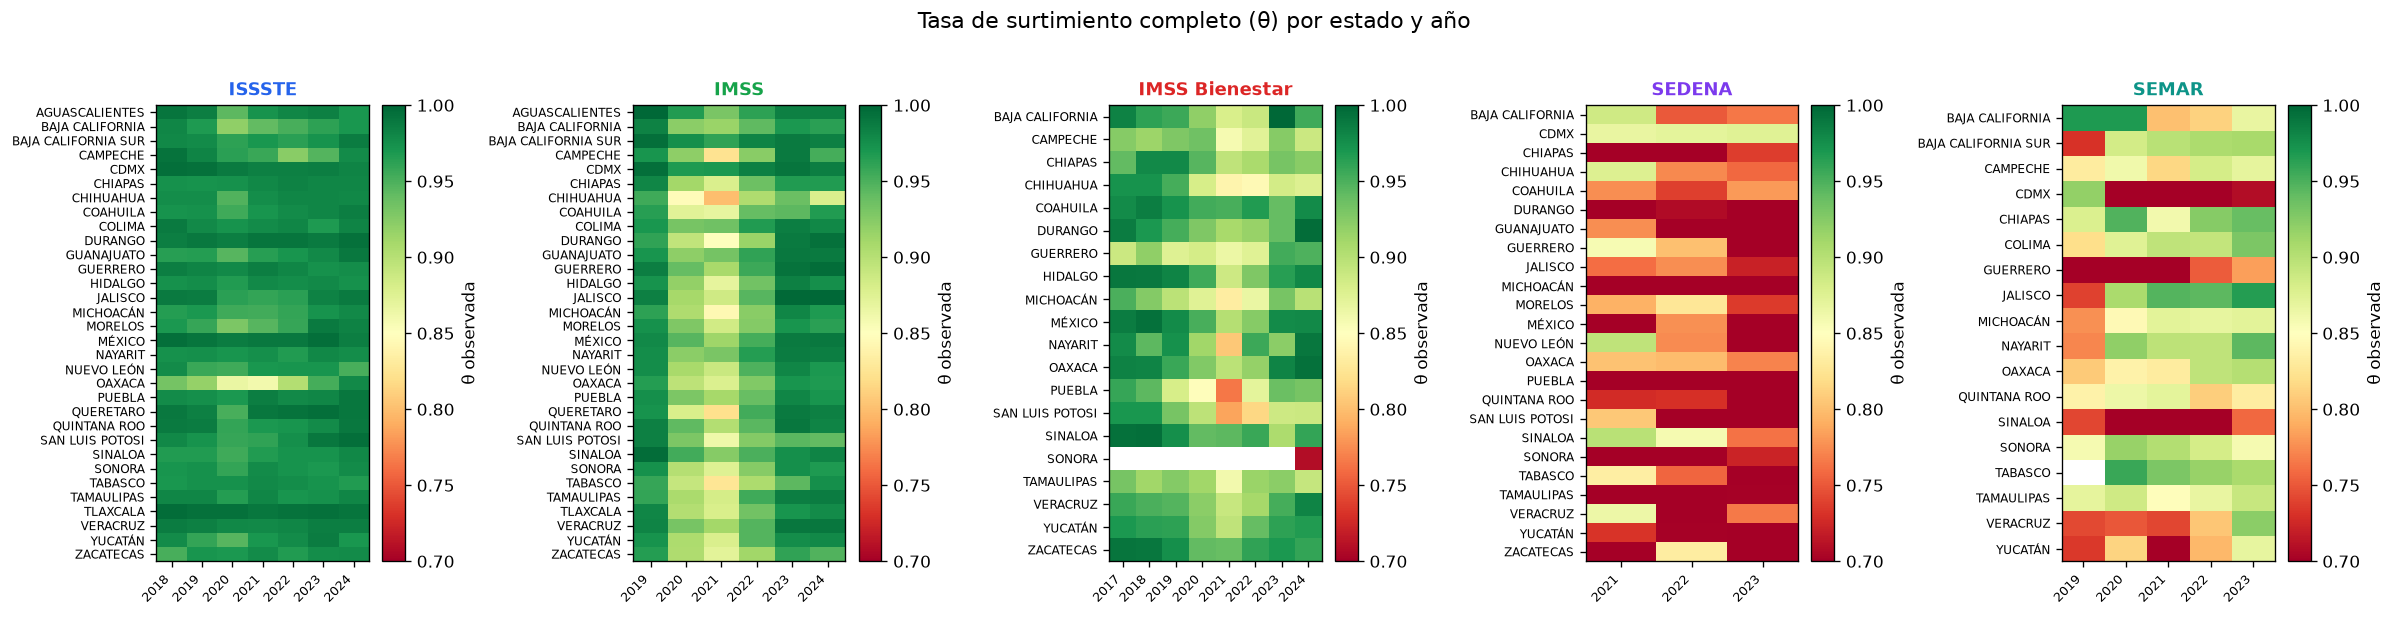

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
instituciones = ['ISSSTE', 'IMSS', 'IMSS Bienestar', 'SEDENA', 'SEMAR']
colores = ['#2563eb', '#16a34a', '#dc2626', '#7c3aed', '#0d9488']

for ax, inst, color in zip(axes, instituciones, colores):
    sub = df[df.institucion == inst].copy()
    pivot = sub.pivot_table(index='estado', columns='anio', values='theta_obs', aggfunc='mean')
    im = ax.imshow(pivot.values, aspect='auto', vmin=0.7, vmax=1.0, cmap='RdYlGn')
    ax.set_title(inst, fontsize=11, fontweight='bold', color=color)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns.astype(int), rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=7)
    plt.colorbar(im, ax=ax, label='θ observada')

fig.suptitle('Tasa de surtimiento completo (θ) por estado y año', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Distribución de θ por institución

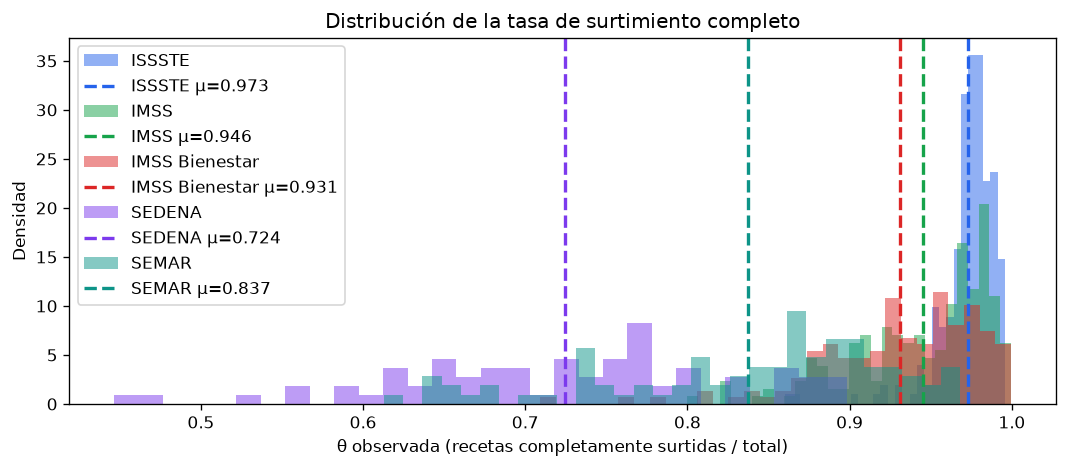

                count    mean     std     min     25%     50%     75%     max
institucion                                                                  
IMSS            192.0  0.9455  0.0414  0.7999  0.9220  0.9600  0.9785  0.9994
IMSS Bienestar  153.0  0.9310  0.0489  0.7090  0.9006  0.9399  0.9693  0.9996
ISSSTE          224.0  0.9730  0.0180  0.8602  0.9684  0.9763  0.9840  0.9958
SEDENA           72.0  0.7244  0.1009  0.4465  0.6540  0.7338  0.7840  0.8987
SEMAR            89.0  0.8373  0.0888  0.6128  0.7837  0.8666  0.9006  0.9681


In [9]:
fig, ax = plt.subplots(figsize=(9, 4))

for inst, color in zip(instituciones, colores):
    sub = df[df.institucion == inst]['theta_obs'].dropna()
    ax.hist(sub, bins=30, alpha=0.5, color=color, label=inst, density=True)
    ax.axvline(sub.mean(), color=color, lw=2, linestyle='--',
               label=f'{inst} μ={sub.mean():.3f}')

ax.set_xlabel('θ observada (recetas completamente surtidas / total)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de la tasa de surtimiento completo')
ax.legend()
plt.tight_layout()
plt.show()

print(df.groupby('institucion')['theta_obs'].describe().round(4))

## 5. Tendencia temporal agregada

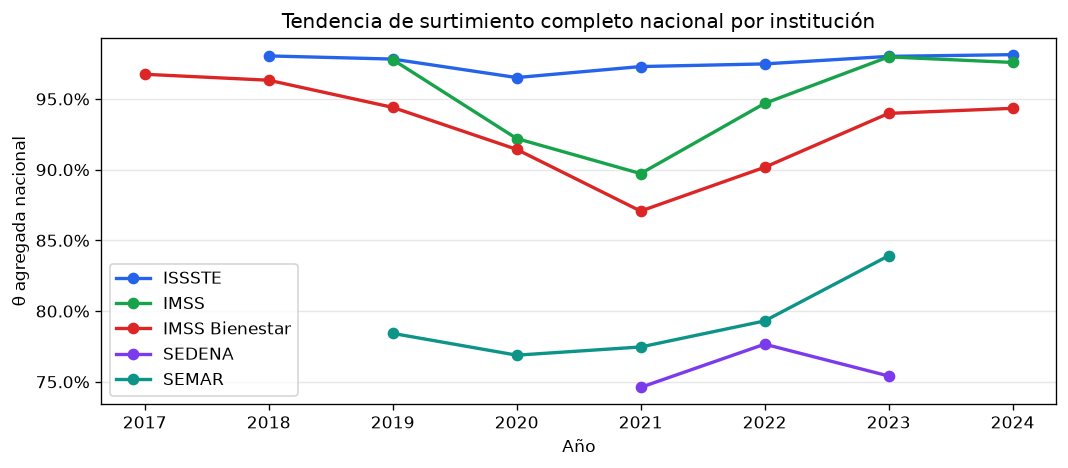

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))

for inst, color in zip(instituciones, colores):
    sub = (
        df[df.institucion == inst]
        .groupby('anio')[['surtidas', 'total']].sum()
        .assign(theta=lambda x: x.surtidas / x.total)
    )
    ax.plot(sub.index, sub['theta'], marker='o', color=color, label=inst, lw=2)

ax.set_xlabel('Año')
ax.set_ylabel('θ agregada nacional')
ax.set_title('Tendencia de surtimiento completo nacional por institución')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.set_xticks(range(2017, 2025))
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Preparar inputs para PyMC

Se construyen los arrays de índices y observaciones usando `build_model_inputs()` del módulo `bayes_data`. Se puede llamar por institución o sobre el dataset completo.

In [11]:
# Filtrar años de análisis: 2019-2023 (período comparable entre las tres instituciones)
# Se excluye 2024 (datos parciales hasta abril) y años anteriores a 2019 (IMSS no tiene)
ANIO_MIN, ANIO_MAX = 2019, 2023

df_modelo = df[df.anio.between(ANIO_MIN, ANIO_MAX) & (df.total > 0)].copy()
df_modelo = df_modelo.drop(columns='theta_obs').reset_index(drop=True)

# Guardar base de análisis
out_path = DATA_DIR / 'base_modelo_2019_2023.csv'
df_modelo.to_csv(out_path, index=False)
print(f"CSV guardado → {out_path}")
print(f"Filas: {len(df_modelo)}  |  columnas: {df_modelo.columns.tolist()}")
print()
print(df_modelo.groupby(['institucion', 'tipo']).agg(
    estados=('estado', 'nunique'),
    anios=('anio', 'nunique'),
    filas=('estado', 'count'),
))

# Inputs por institución sobre la base filtrada
inputs = {}
for inst in instituciones:
    sub = df_modelo[df_modelo.institucion == inst].copy()
    inputs[inst] = build_model_inputs(sub)
    d = inputs[inst]
    print(f"\n{inst}: {len(d['n_obs'])} obs | "
          f"{len(d['coords']['estados'])} estados | "
          f"años: {d['coords']['anios']} | "
          f"θ_obs médiana={np.median(d['theta_obs']):.4f}")

CSV guardado → C:\Users\Oscar David\Documents\Maestría_local\Tercer_trimestre\Introduction_to_probabilistic_programming\final-project-pp-dj\data\base_modelo_2019_2023.csv
Filas: 576  |  columnas: ['estado', 'anio', 'surtidas', 'total', 'institucion', 'tipo']

                        estados  anios  filas
institucion    tipo                          
IMSS           civil         32      5    160
IMSS Bienestar civil         19      5     95
ISSSTE         civil         32      5    160
SEDENA         militar       24      3     72
SEMAR          militar       18      5     89

ISSSTE: 160 obs | 32 estados | años: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)] | θ_obs médiana=0.9737

IMSS: 160 obs | 32 estados | años: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)] | θ_obs médiana=0.9459

IMSS Bienestar: 95 obs | 19 estados | años: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)] | θ_obs mé

In [13]:
from bayes_data_david import build_model_inputs_c, build_model_inputs

data_c = build_model_inputs_c(df_modelo)

print("Instituciones:", data_c["coords"]["institucion"])
print("Tipos:", data_c["coords"]["tipo"])
print("inst_to_tipo:", data_c["inst_to_tipo"])
print()
print("N observaciones:", len(data_c["n_obs"]))
print("N estados:", len(data_c["coords"]["estado"]), "| max estado_idx:", data_c["estado_idx"].max())
print("N años:", len(data_c["coords"]["anio"]), "| max anio_idx:", data_c["anio_idx"].max())
print("θ_obs mediana:", np.median(data_c["theta_obs"]))


Instituciones: ['IMSS', 'IMSS Bienestar', 'ISSSTE', 'SEDENA', 'SEMAR']
Tipos: ['civil', 'militar']
inst_to_tipo: [0 0 0 1 1]

N observaciones: 576
N estados: 32 | max estado_idx: 31
N años: 5 | max anio_idx: 4
θ_obs mediana: 0.9385996858619774
